# Notebook for preprocessing GFAS fire emission prior

In [72]:
import xarray as xr
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs

# Examine the original data structure

In [5]:
DATA_PATH = "/home/pietaril/Documents/data/GFAS/original_GFAS_data/GFAS_CO2_2018.nc"
ds = xr.open_dataset(DATA_PATH)
ds



<xarray.Dataset>
Dimensions:     (valid_time: 365, latitude: 1800, longitude: 3600)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2018-01-01 2018-01-02 ... 2018-12-31
  * latitude    (latitude) float64 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * longitude   (longitude) float64 0.05 0.15 0.25 0.35 ... 359.8 359.9 359.9
Data variables:
    co2fire     (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-01-14T15:04 GRIB to CDM+CF via cfgrib-0.9.1...

# Helper functions to preprocess GFAS-type data

In [73]:



def select_area(aoi, ds):
    # Select the area based on area of interest
    
    area_subset = ds.sel(longitude=slice(aoi[0], aoi[1]),
                    latitude=slice(aoi[2], aoi[3]))
    return area_subset


def preprocess_gfas(aoi, ds):
    # order the latitude in ascending order (it's descending in the original)
    out = ds.sortby(ds.latitude)
    out.latitude.attrs.update({"stored_direction": "increasing"},)


    # convert longitudes from range 0-360 to -180, 180
    out.coords['longitude'] = (out.coords['longitude'] + 180) % 360 - 180
    out = out.sortby(out.longitude)

    #select aoi
    out = select_area(aoi, out)

    #drop attributes copied from the initial dataset
    out.attrs = {}
    out.attrs.update({"description": "Preprocessed CO2 fire emissions from GFAS. Units and variable names changed from the original to comply with CIF",
                        "units": "kg m-2 hr-1"})

    #rename variables to match CIF standard
    rename_map = {
        "valid_time" : "time",
        "co2fire": "emi_fire"
    }

    out = out.rename(rename_map)
    out.emi_fire.attrs = {}


    #convert to float64
    out["emi_fire"] = out["emi_fire"].astype("float64")

    #convert units from kg/m2/s to kg/m2/hr
    out["emi_fire"] = out["emi_fire"]*60*60

    return out

def write_to_file(dsout, OUT_PATH):
    # Save the result to a new NetCDF file
    year = dsout["time"].dt.year.values[0]
    # Write the output dataset to a new NetCDF file
    fname = f"fire_prior_GFAS_CO2_{year}.nc"
    dsout.to_netcdf(os.path.join(OUT_PATH,fname), encoding={'time':{'units': "days since 1900-01-01"}})
    


In [76]:
DATA_PATH = "/home/pietaril/Documents/data/GFAS/original_GFAS_data/"
OUT_PATH = "/home/pietaril/Documents/data/GFAS/fire_prior_CIF_FLEXPART_CO2M_domain_-12_35_35_72/"
aoi = [-12, 35, 35, 72]


fnames = [os.path.join(DATA_PATH,f) for f in os.listdir(DATA_PATH) if f.endswith(".nc")]
for fname in fnames:
    ds = xr.open_dataset(fname)
    out = preprocess_gfas(aoi, ds)
    write_to_file(out, OUT_PATH)
    ds.close()







# Examine the created files

In [41]:
OUT_PATH = "/home/pietaril/Documents/data/GFAS/fire_prior_CIF_FLEXPART_CO2M_12_35_35_72/"

fnames = [os.path.join(OUT_PATH,f) for f in os.listdir(OUT_PATH) if f.endswith(".nc")]

ds = xr.open_dataset(fnames[2])
ds

<xarray.Dataset>
Dimensions:    (time: 365, latitude: 390, longitude: 550)
Coordinates:
  * time       (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2017-12-31
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
Data variables:
    emi_fire   (time, latitude, longitude) float64 ...
Attributes:
    description:  Preprocessed CO2 fire emissions from GFAS. Units and variab...
    units:        kg m-2 hr-1

# Conversion to g m-2 yr-1 for Tuulas plots

In [23]:
def to_g_per_m2_per_yr(ds):
    time = ds["time"].values[0]
    #per hour to per day + kg to g
    out = ds["emi_fire"]*24*1000
    #sum the daily values
    out = out.sum(dim="time")

    out = out.to_dataset()

    out.coords["time"] = (time) 
    out = out.expand_dims("time")
    return out

In [29]:
datasets = []
for fname in fnames:
    ds = xr.open_dataset(fname)
    #year = ds["time"].dt.year.values[0]
    #only take 10 years to get nice arrangement of subplots
    #if year > 2013:
    yearly = to_g_per_m2_per_yr(ds)
    datasets.append(yearly)


ds_allyears = xr.concat(datasets, dim="time") 
ds_allyears = ds_allyears.sortby("time")
ds_allyears


<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550, time: 11)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
  * time       (time) datetime64[ns] 2013-01-01 2014-01-01 ... 2023-01-01
Data variables:
    emi_fire   (time, latitude, longitude) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [22]:
#need to add the time coordinate for the yearly datasets

yearly

<xarray.Dataset>
Dimensions:    (latitude: 390, longitude: 550)
Coordinates:
  * latitude   (latitude) float64 34.05 34.15 34.25 34.35 ... 72.75 72.85 72.95
  * longitude  (longitude) float64 -14.95 -14.85 -14.75 ... 39.75 39.85 39.95
Data variables:
    emi_fire   (latitude, longitude) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

# Plotting functions

In [57]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap



def plot_yearly_fluxes(ds, variable, ncols, cmap, cbar_label, suptitle=None):
    # Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
    data = ds[variable]

    # Define colorbar shrink parameter
    cbar_shrink = 0.8

    # Create the plot
    g = data.plot.pcolormesh(
        x="longitude",
        y="latitude",
        col="time",
        col_wrap=ncols,
        robust=True,
        aspect=1.25,
        cmap=cmap,
        subplot_kws=dict(projection=ccrs.PlateCarree()),
        cbar_kwargs=dict(label="fire prior emission [Mt(CO$_2$)/year]", shrink=cbar_shrink),
    )

    # Calculate the total number of subplots (including blanks)
    nplots = len(data.time)  # Total number of time slices
    nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

    # Adjust axes to handle blank spaces correctly
    for i, ax in enumerate(g.axes.flat):
        if i < nplots:  # Plot only for valid time slices
            time = str(data.time.values[i])[0:4]
            ax.set_title(time)
            ax.coastlines()
        else:  # Completely remove unused subplots
            g.fig.delaxes(ax)

    # Adjust the suptitle to account for the colorbar space
    # Compute the amount to shift the title leftward
    colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
    title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

    # Add the suptitle and position it
    if not suptitle==None:
        g.fig.suptitle(
            suptitle,
            fontsize=18,
            x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
            y=0.9,  
        )

    # Adjust the spacing
    g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

    # Draw the plot
    plt.draw()

In [70]:
#select Scandinavia

aoi_scand = [3, 31, 53, 73]

scand = select_area(aoi_scand, ds_allyears)

cbar_label = "emission [Mt(CO$_2$)/year]"
variable = "emi_fire"
ncols = 4
cmap = truncate_colormap(mpl.colormaps["RdBu_r"], minval=0.5)
suptitle="GFAS yearly CO$_2$ emissions"


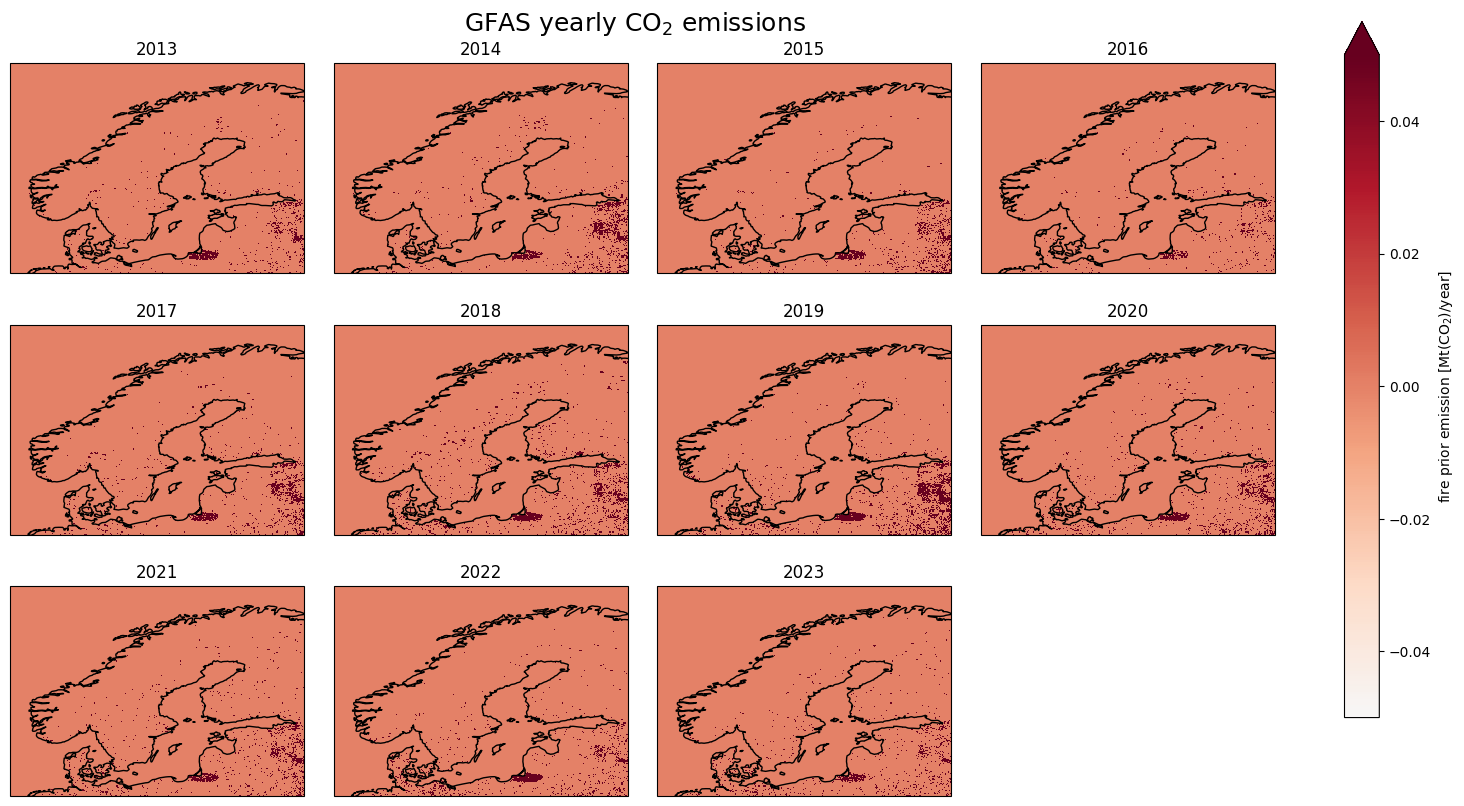

In [71]:
plot_yearly_fluxes(scand, "emi_fire", ncols, cmap, cbar_label, suptitle)

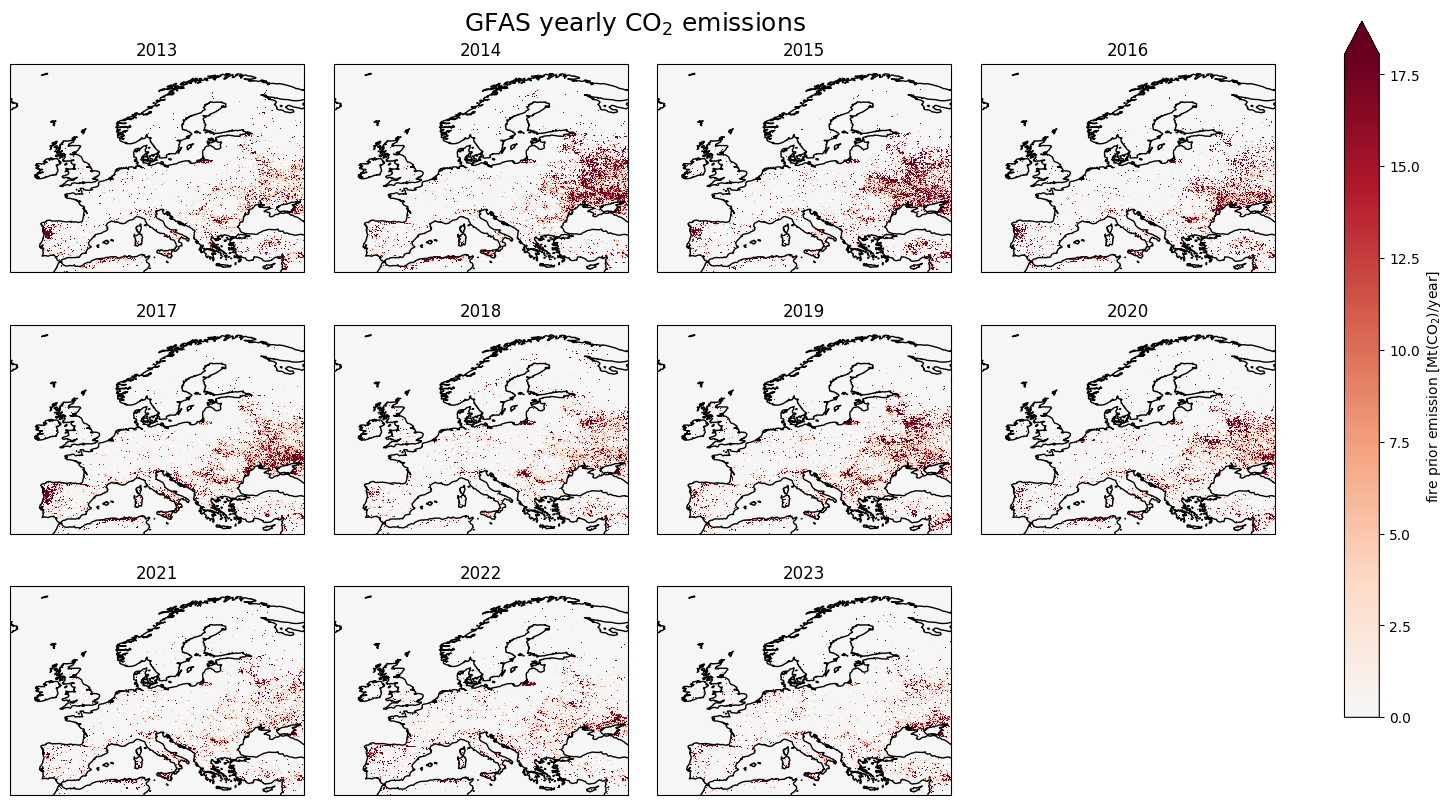

In [66]:
plot_yearly_fluxes(ds_allyears, variable, ncols, cmap, cbar_label, suptitle)
figpath = "/home/pietaril/Documents/plots/GFAS/"
figname = f"GFAS_yearly_CO2_emissions.png"
plt.savefig(figpath+figname)
plt.draw()

<Figure size 640x480 with 0 Axes>

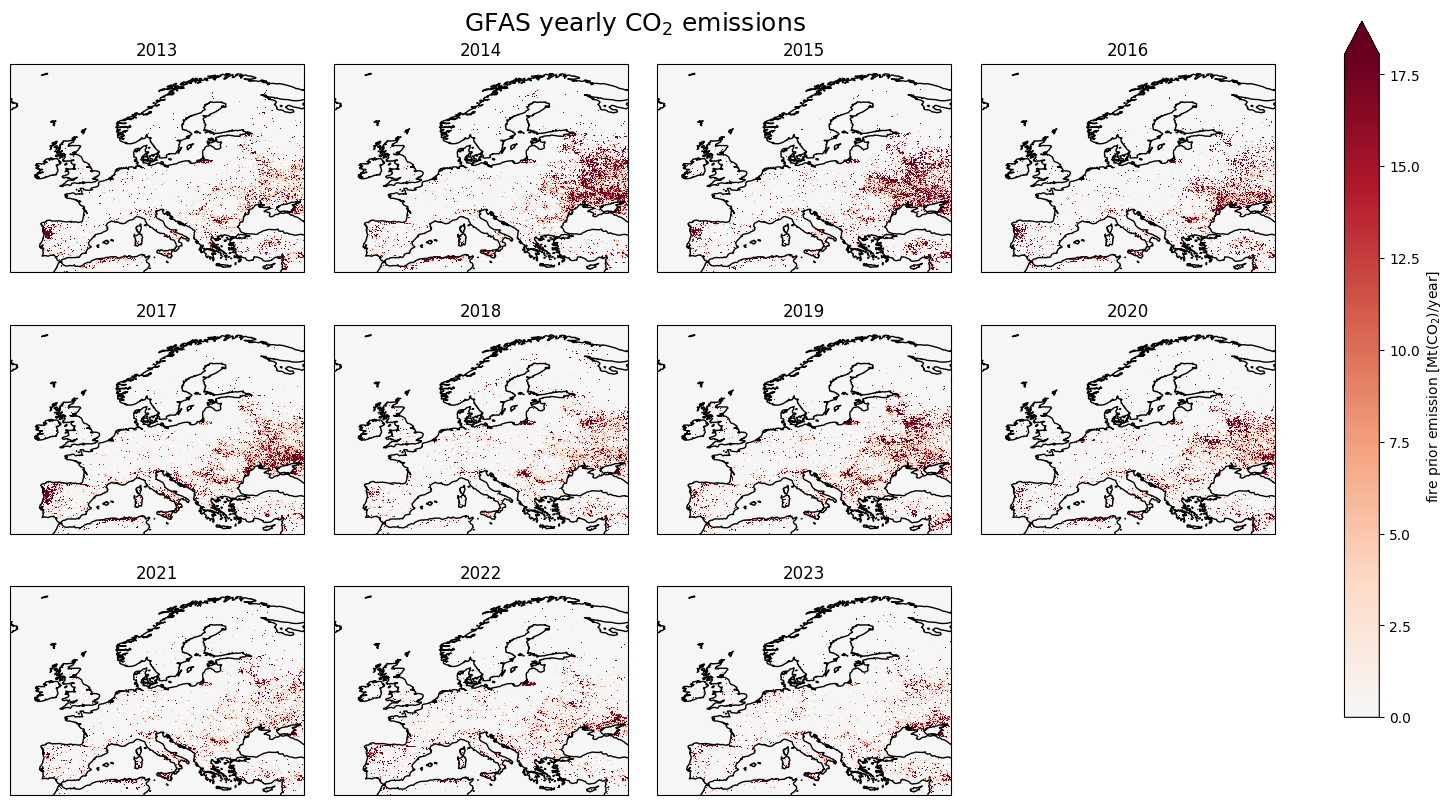

In [ ]:




ncols = 4  # Number of columns in the subplot grid
cmap = truncate_colormap(mpl.colormaps["RdBu_r"], minval=0.5)
# Sample data from your dataset (replace 'ds_allyears' and 'emi_fire' with your data variables)
data = ds_allyears["emi_fire"].sel()

# Define colorbar shrink parameter
cbar_shrink = 0.8

# Create the plot
g = data.plot.pcolormesh(
    x="longitude",
    y="latitude",
    col="time",
    col_wrap=ncols,
    robust=True,
    aspect=1.25,
    cmap=cmap,
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    cbar_kwargs=dict(label="fire prior emission [Mt(CO$_2$)/year]", shrink=cbar_shrink),
)

# Calculate the total number of subplots (including blanks)
nplots = len(data.time)  # Total number of time slices
nrows = (nplots + ncols - 1) // ncols  # Calculate number of rows (rounding up)

# Adjust axes to handle blank spaces correctly
for i, ax in enumerate(g.axes.flat):
    if i < nplots:  # Plot only for valid time slices
        time = str(data.time.values[i])[0:4]
        ax.set_title(time)
        ax.coastlines()
    else:  # Completely remove unused subplots
        g.fig.delaxes(ax)

# Adjust the suptitle to account for the colorbar space
# Compute the amount to shift the title leftward
colorbar_offset = (1 - cbar_shrink) / 2  # Fraction of the figure width
title_x_adjustment = colorbar_offset * g.fig.get_figwidth()

# Add the suptitle and position it
g.fig.suptitle(
    "GFAS yearly CO$_2$ emissions",
    fontsize=18,
    x=0.5 - title_x_adjustment / g.fig.get_figwidth(),  # Centered and adjusted left
    y=0.9,  
)

# Adjust the spacing
g.fig.subplots_adjust(top=0.85, right=0.8, wspace=0.1, hspace=0.15)

# Draw the plot
plt.draw()

figpath = "/home/pietaril/Documents/plots/GFAS/"
figname = f"GFAS_yearly_CO2_emissions.png"
plt.savefig(figpath+figname)
plt.draw()

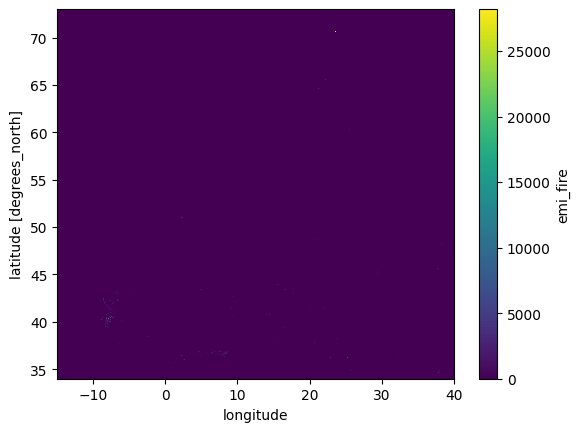

In [46]:
yearly.plot.pcolormesh(x="longitude", y="latitude")

In [34]:



monthly_mean = ds.resample(time='M').mean()
monthly_max = ds.resample(time='M').max()


aug = ds.sel(time=slice("2018-08-01", "2018-08-31"))




In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


def plot_fluxmaps(ds, figpath=None):
    data = ds["emi_fire"]
    g = data.plot.pcolormesh(x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
                     subplot_kws=dict(projection=ccrs.PlateCarree()), cbar_kwargs = dict(label = "fire CO$_2$ prior flux [$kg$ $m^{-2} hr^{-1}$]", shrink=0.9 ),

    )


    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()

    if not figpath==None:
        figname = f"Fire_CO2_fluxmaps_{time[0:4]}.png"
        plt.savefig(figpath+figname)
        plt.draw()

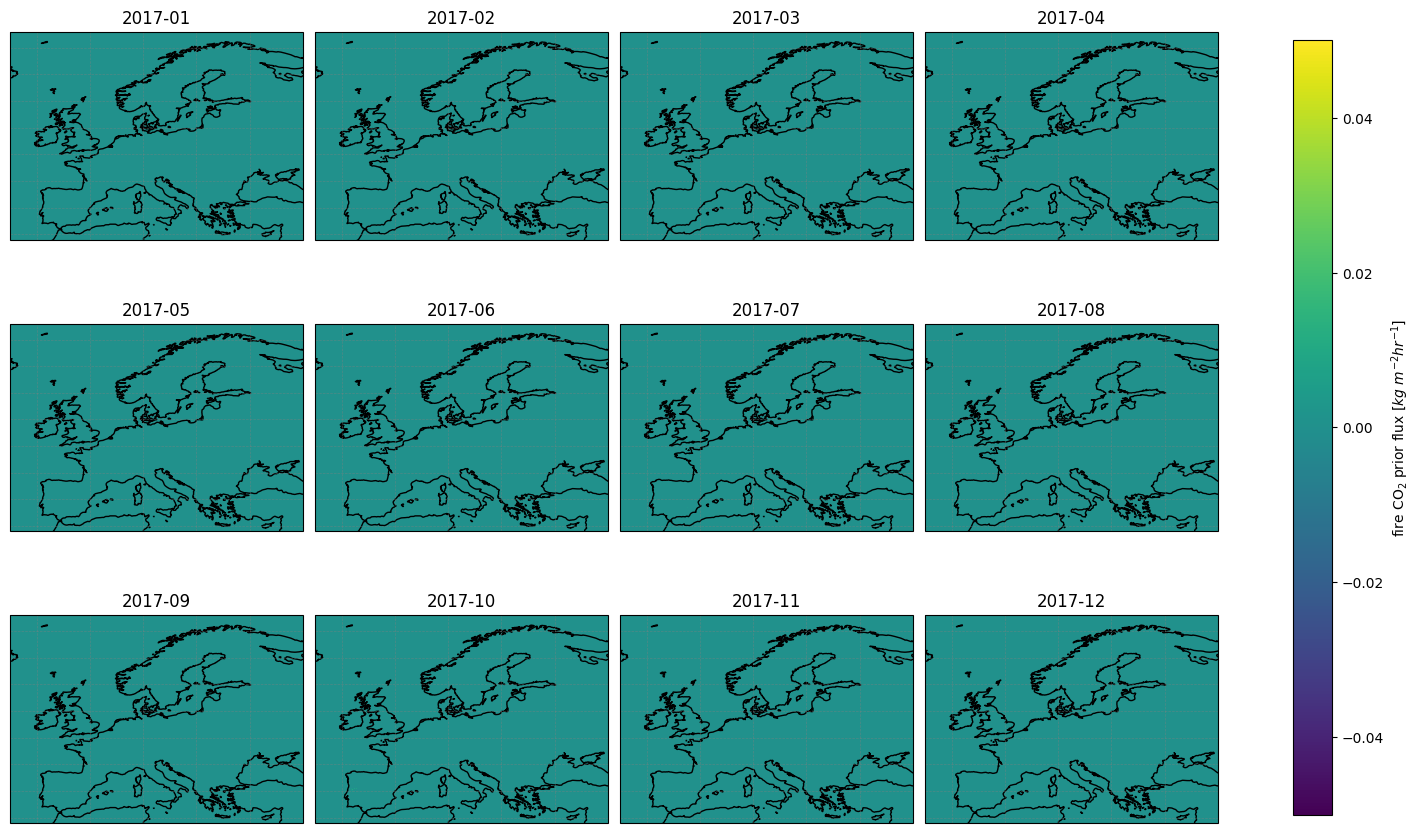

In [36]:
plot_fluxmaps(monthly_mean)

# Trying logarithmic colorscale

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs


def plot_fluxmaps(ds, figpath=None, norm=None, cmap="viridis"):
    """
    Plot flux maps with optional SymLogNorm normalization and colormap selection.

    Parameters:
    - ds: xarray Dataset containing "emi_fire" data.
    - figpath: Path to save the figure (default is None, meaning no saving).
    - norm: Normalization (e.g., SymLogNorm) to apply to the colormap.
    - cmap: Colormap name (default is "viridis").
    """
    data = ds["emi_fire"]
    
    # Apply colormap and normalization
    g = data.plot.pcolormesh(
        x="longitude", y="latitude", col="time", col_wrap=4, robust=True, aspect=1.2,
        cmap=cmap, norm=norm,
        subplot_kws=dict(projection=ccrs.PlateCarree()), 
        cbar_kwargs=dict(
            label="fire CO$_2$ prior flux [$kg$ $m^{-2} hr^{-1}$]", 
            shrink=0.9
        ),
    )

    # Add coastlines, gridlines, and titles to subplots
    for i, ax in enumerate(g.axes.flat):
        time = str(data.time.values[i])[0:7]
        ax.set_title(time)
        ax.coastlines()
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

    plt.draw()

    # Save the figure if figpath is specified
    if figpath is not None:
        figname = f"Fire_CO2_fluxmaps_{time[0:4]}.png"
        plt.savefig(figpath + figname)
        plt.draw()

In [22]:
monthly_mean["emi_fire"].values.flatten().max()

0.008833708311833048

In [41]:
vmin = monthly_mean["emi_fire"].values.flatten().min()
vmax = monthly_mean["emi_fire"].values.flatten().max()
print(vmin, vmax)

0.0 0.03915392066119239


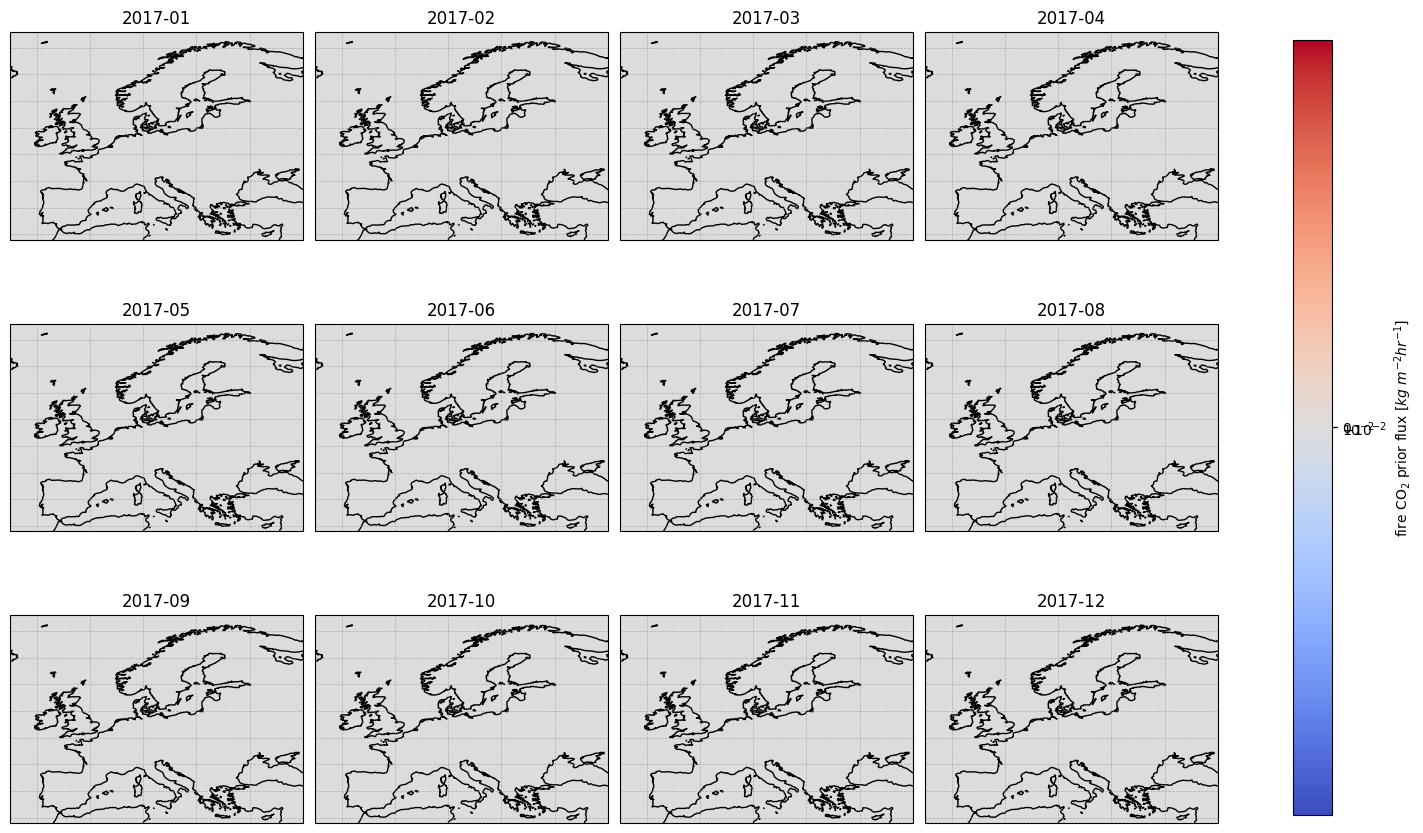

In [43]:
import matplotlib.colors as colors


norm =colors.SymLogNorm(linthresh=0.03, linscale=0.000001, vmin=-vmax, vmax=vmax, base=10)
plot_fluxmaps(monthly_mean, cmap="coolwarm", norm=norm)

TypeError: '<' not supported between instances of 'float' and 'property'

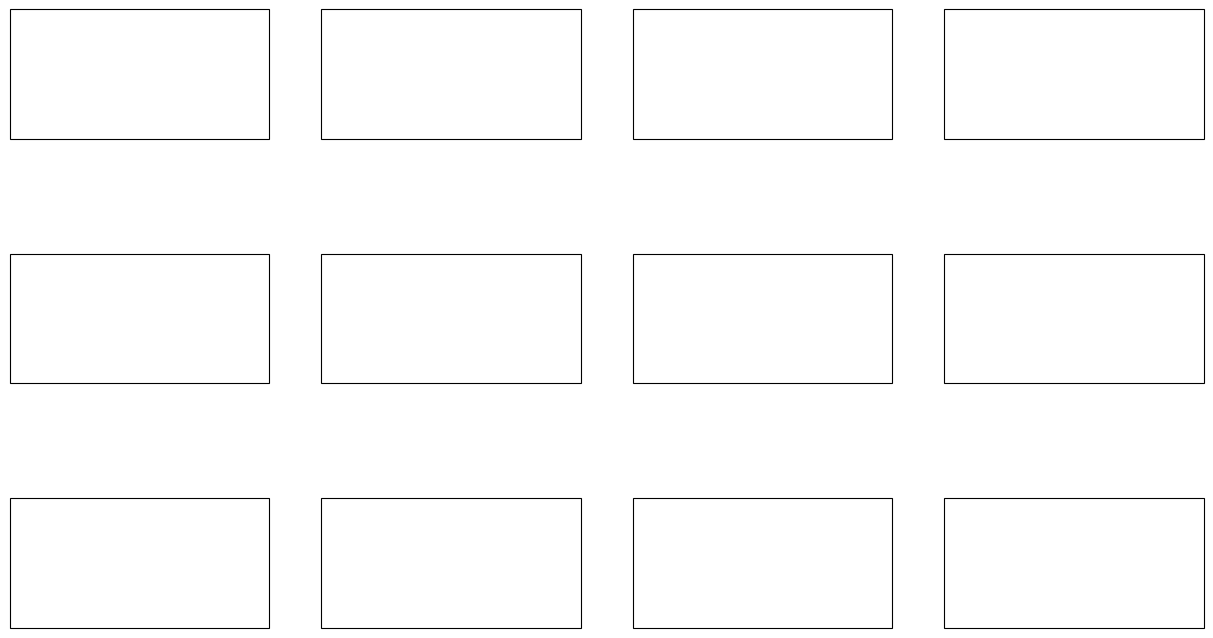

In [11]:
cmap = cm.bwr
plot_fluxmaps(monthly_mean, cmap)